In [ ]:
!pip install pandas numpy matplotlib seaborn scikit-learn -q
print("Done!")

Done!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print("All imports successful!")

All imports successful!


In [ ]:
df = pd.read_csv('TMDB_movie_dataset_v11.csv')
print(f"Full dataset: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst look:")
print(df.head(3))

Full dataset: (1399719, 24)

Columns: ['id', 'title', 'vote_average', 'vote_count', 'status', 'release_date', 'revenue', 'runtime', 'adult', 'backdrop_path', 'budget', 'homepage', 'imdb_id', 'original_language', 'original_title', 'overview', 'popularity', 'poster_path', 'tagline', 'genres', 'production_companies', 'production_countries', 'spoken_languages', 'keywords']

First look:
       id            title  vote_average  vote_count    status release_date  \
0   27205        Inception         8.364       34495  Released   2010-07-15   
1  157336     Interstellar         8.417       32571  Released   2014-11-05   
2     155  The Dark Knight         8.512       30619  Released   2008-07-16   

      revenue  runtime  adult                     backdrop_path  ...  \
0   825532764      148  False  /8ZTVqvKDQ8emSGUEMjsS4yHAwrp.jpg  ...   
1   701729206      169  False  /pbrkL804c8yAv3zBZR4QPEafpAR.jpg  ...   
2  1004558444      152  False  /nMKdUUepR0i5zn0y1T4CsSB5chy.jpg  ...   

    origi

In [ ]:
print("=== DATASET INFO ===")
print(df.info())

print("\n=== MISSING VALUES ===")
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'missing': missing, 'percent': missing_pct})
print(missing_df[missing_df['missing'] > 0])

=== DATASET INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1399719 entries, 0 to 1399718
Data columns (total 24 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   id                    1399719 non-null  int64  
 1   title                 1399701 non-null  object 
 2   vote_average          1399719 non-null  float64
 3   vote_count            1399719 non-null  int64  
 4   status                1399719 non-null  object 
 5   release_date          1094326 non-null  object 
 6   revenue               1399719 non-null  int64  
 7   runtime               1399719 non-null  int64  
 8   adult                 1399719 non-null  bool   
 9   backdrop_path         349364 non-null   object 
 10  budget                1399719 non-null  int64  
 11  homepage              144271 non-null   object 
 12  imdb_id               664195 non-null   object 
 13  original_language     1399719 non-null  object 
 14  original_titl

In [ ]:
# Drop columns we don't need for prediction
drop_cols = ['backdrop_path', 'homepage', 'poster_path',
             'tagline', 'imdb_id', 'keywords']
df = df.drop(columns=drop_cols)

# Keep only released movies
df = df[df['status'] == 'Released']

# Drop rows missing critical fields
df = df.dropna(subset=['budget', 'revenue', 'genres',
                        'release_date', 'overview'])

# Remove movies with zero budget or revenue (means data is missing)
df = df[df['budget'] > 0]
df = df[df['revenue'] > 0]

# Reset index
df = df.reset_index(drop=True)

print(f"Clean dataset: {df.shape}")
print(f"\nMissing values remaining:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Clean dataset: (12188, 18)

Missing values remaining:
production_companies    1082
production_countries    1081
spoken_languages         838
dtype: int64


In [ ]:
# Calculate ROI
df['roi'] = df['revenue'] / df['budget']

# Hit = 1 if ROI > 1 (profitable), Flop = 0 if ROI <= 1
df['hit'] = (df['roi'] > 1).astype(int)

print("Hit/Flop distribution:")
print(df['hit'].value_counts())
print(f"\nHit rate: {df['hit'].mean()*100:.1f}%")
print(f"Flop rate: {(1-df['hit'].mean())*100:.1f}%")

Hit/Flop distribution:
hit
1    7583
0    4605
Name: count, dtype: int64

Hit rate: 62.2%
Flop rate: 37.8%


In [ ]:
df['release_date'] = pd.to_datetime(df['release_date'])
df['release_year'] = df['release_date'].dt.year
df['release_month'] = df['release_date'].dt.month

print("Release year range:")
print(f"  Earliest: {df['release_year'].min()}")
print(f"  Latest:   {df['release_year'].max()}")

print("\nMovies per release month:")
print(df['release_month'].value_counts().sort_index())

Release year range:
  Earliest: 1898
  Latest:   2026

Movies per release month:
release_month
1      890
2      859
3      946
4      911
5      966
6     1013
7      901
8     1036
9     1220
10    1240
11     970
12    1236
Name: count, dtype: int64


In [ ]:
df['primary_genre'] = df['genres'].str.split(',').str[0].str.strip()

print("Top 15 genres:")
print(df['primary_genre'].value_counts().head(15))

print(f"\nTotal unique genres: {df['primary_genre'].nunique()}")

Top 15 genres:
primary_genre
Drama              2859
Comedy             2508
Action             1696
Horror              895
Adventure           627
Thriller            537
Crime               512
Animation           397
Documentary         395
Romance             347
Science Fiction     293
Fantasy             246
Family              229
Music               187
Mystery             185
Name: count, dtype: int64

Total unique genres: 19


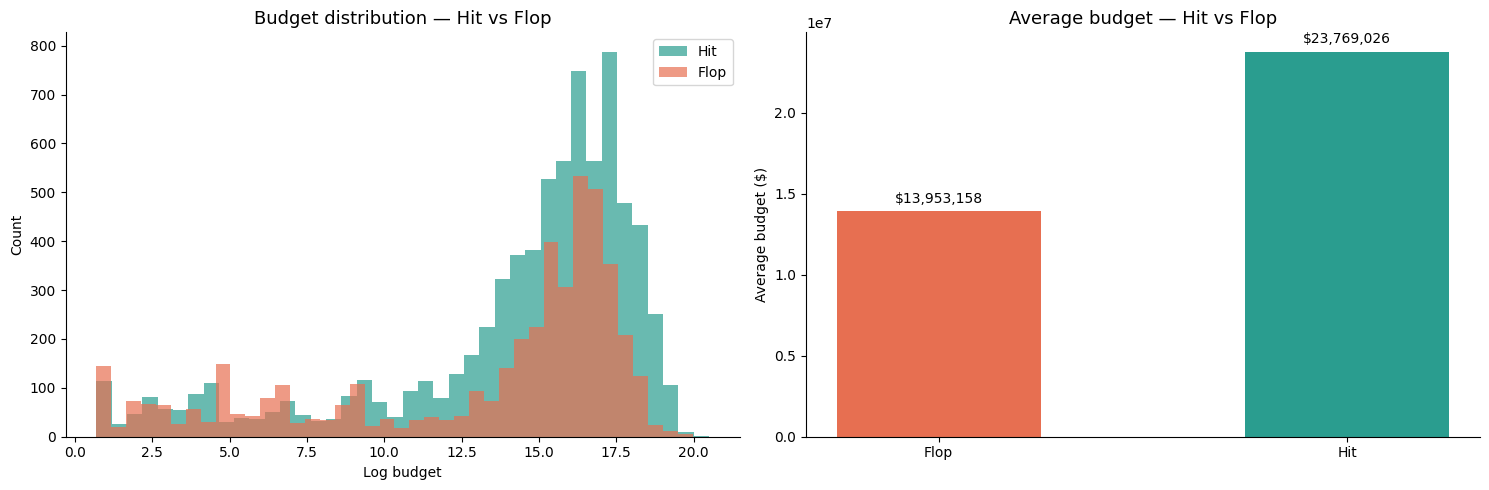

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1 - Budget distribution by hit/flop
axes[0].hist(np.log1p(df[df['hit']==1]['budget']),
             bins=40, alpha=0.7, color='#2a9d8f', label='Hit')
axes[0].hist(np.log1p(df[df['hit']==0]['budget']),
             bins=40, alpha=0.7, color='#e76f51', label='Flop')
axes[0].set_title('Budget distribution — Hit vs Flop', fontsize=13)
axes[0].set_xlabel('Log budget')
axes[0].set_ylabel('Count')
axes[0].legend()

# Plot 2 - Avg budget by hit/flop
avg_budget = df.groupby('hit')['budget'].mean()
bars = axes[1].bar(['Flop', 'Hit'], avg_budget.values,
                    color=['#e76f51', '#2a9d8f'], width=0.5)
axes[1].set_title('Average budget — Hit vs Flop', fontsize=13)
axes[1].set_ylabel('Average budget ($)')
for bar, val in zip(bars, avg_budget.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500000,
                f'${val:,.0f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('budget_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

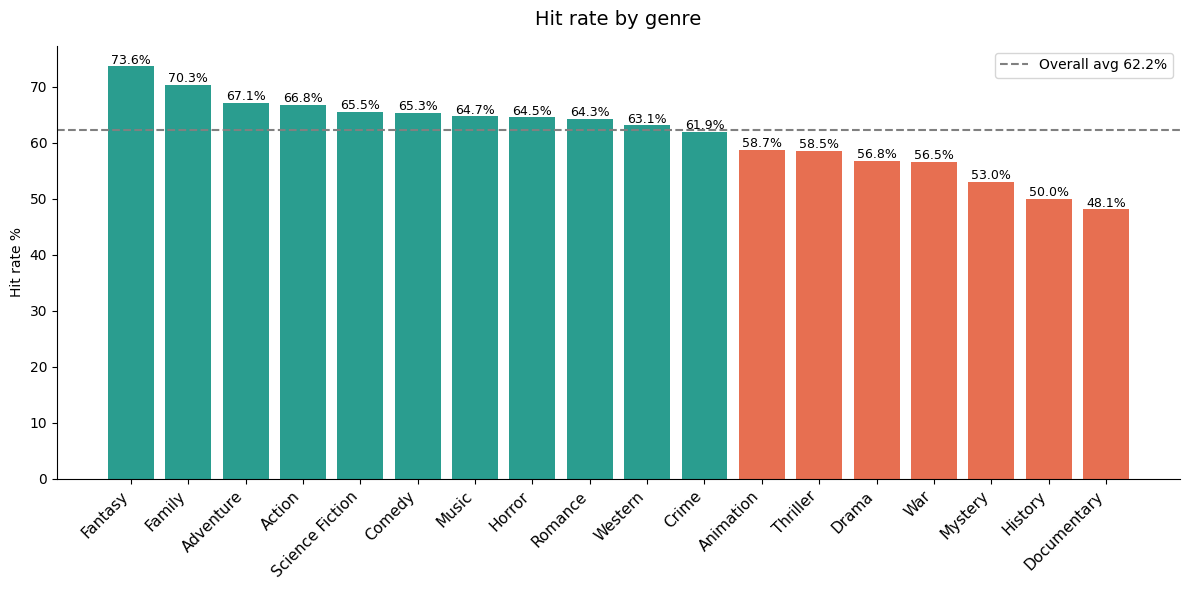

  primary_genre  total  hit_rate
        Fantasy    246      73.6
         Family    229      70.3
      Adventure    627      67.1
         Action   1696      66.8
Science Fiction    293      65.5
         Comedy   2508      65.3
          Music    187      64.7
         Horror    895      64.5
        Romance    347      64.3
        Western     84      63.1
          Crime    512      61.9
      Animation    397      58.7
       Thriller    537      58.5
          Drama   2859      56.8
            War    108      56.5
        Mystery    185      53.0
        History     72      50.0
    Documentary    395      48.1


In [ ]:
genre_stats = df.groupby('primary_genre').agg(
    total=('hit', 'count'),
    hits=('hit', 'sum')
).reset_index()

genre_stats['hit_rate'] = (genre_stats['hits'] / genre_stats['total'] * 100).round(1)
genre_stats = genre_stats[genre_stats['total'] >= 50].sort_values('hit_rate', ascending=False)

plt.figure(figsize=(12, 6))
bars = plt.bar(genre_stats['primary_genre'], genre_stats['hit_rate'],
               color=['#2a9d8f' if x > 60 else '#e76f51' for x in genre_stats['hit_rate']])
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.title('Hit rate by genre', fontsize=14, pad=15)
plt.ylabel('Hit rate %')
plt.axhline(y=62.2, color='gray', linestyle='--', label='Overall avg 62.2%')
plt.legend()
for bar, val in zip(bars, genre_stats['hit_rate']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val}%', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('genre_hit_rate.png', dpi=150, bbox_inches='tight')
plt.show()

print(genre_stats[['primary_genre', 'total', 'hit_rate']].to_string(index=False))

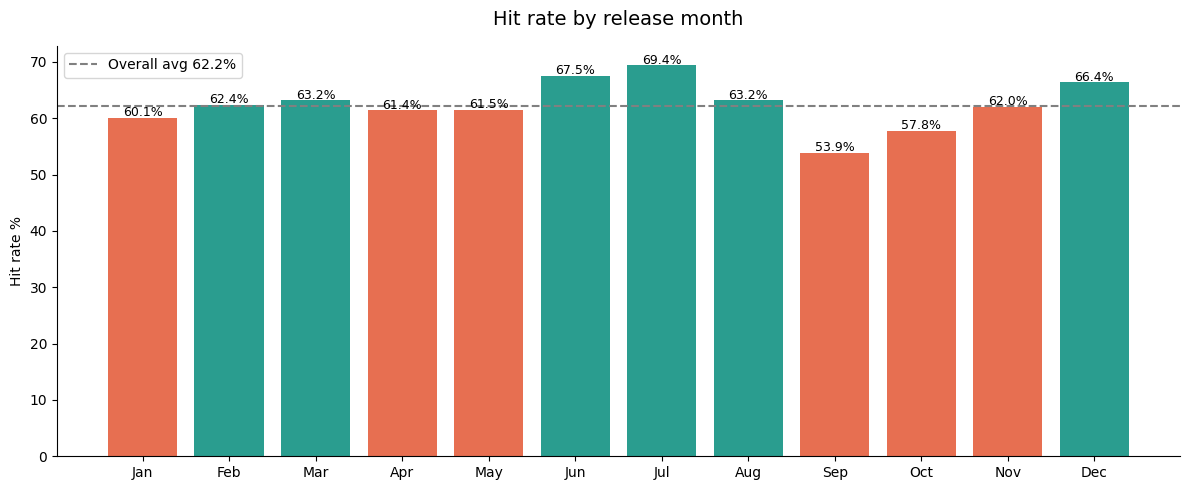

In [ ]:
month_stats = df.groupby('release_month').agg(
    total=('hit', 'count'),
    hit_rate=('hit', 'mean')
).reset_index()
month_stats['hit_rate'] = (month_stats['hit_rate'] * 100).round(1)

month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']
month_stats['month_name'] = month_names

plt.figure(figsize=(12, 5))
bars = plt.bar(month_stats['month_name'], month_stats['hit_rate'],
               color=['#2a9d8f' if x > 62 else '#e76f51' for x in month_stats['hit_rate']])
plt.title('Hit rate by release month', fontsize=14, pad=15)
plt.ylabel('Hit rate %')
plt.axhline(y=62.2, color='gray', linestyle='--', label='Overall avg 62.2%')
plt.legend()
for bar, val in zip(bars, month_stats['hit_rate']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val}%', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('month_hit_rate.png', dpi=150, bbox_inches='tight')
plt.show()

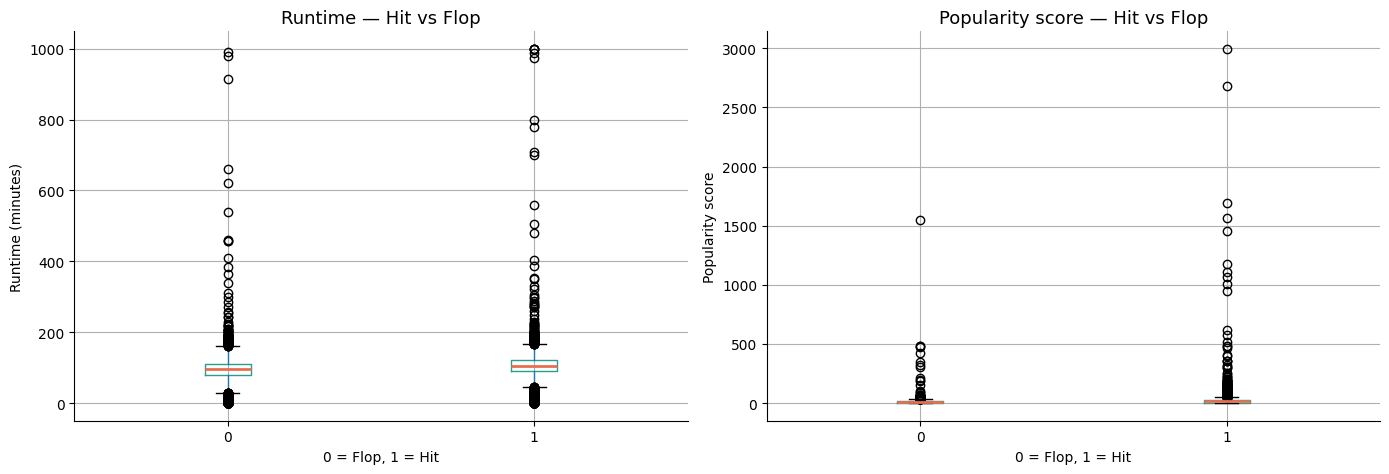

Avg runtime — Hits:  102.4 mins
Avg runtime — Flops: 87.3 mins

Avg popularity — Hits:  19.95
Avg popularity — Flops: 9.47


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1 - Runtime by hit/flop
df.boxplot(column='runtime', by='hit', ax=axes[0],
           boxprops=dict(color='#2a9d8f'),
           medianprops=dict(color='#e76f51', linewidth=2))
axes[0].set_title('Runtime — Hit vs Flop', fontsize=13)
axes[0].set_xlabel('0 = Flop, 1 = Hit')
axes[0].set_ylabel('Runtime (minutes)')

# Plot 2 - Popularity by hit/flop
df.boxplot(column='popularity', by='hit', ax=axes[1],
           boxprops=dict(color='#2a9d8f'),
           medianprops=dict(color='#e76f51', linewidth=2))
axes[1].set_title('Popularity score — Hit vs Flop', fontsize=13)
axes[1].set_xlabel('0 = Flop, 1 = Hit')
axes[1].set_ylabel('Popularity score')

plt.suptitle('')
plt.tight_layout()
plt.savefig('runtime_popularity.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Avg runtime — Hits:  {df[df['hit']==1]['runtime'].mean():.1f} mins")
print(f"Avg runtime — Flops: {df[df['hit']==0]['runtime'].mean():.1f} mins")
print(f"\nAvg popularity — Hits:  {df[df['hit']==1]['popularity'].mean():.2f}")
print(f"Avg popularity — Flops: {df[df['hit']==0]['popularity'].mean():.2f}")

In [16]:
print("quick summary before moving to models\n")
print(f"clean dataset: 12,188 movies, 62.2% hits, 37.8% flops")
print(f"\nwhat actually matters:")
print(f"  - budget: hits avg $23.7M vs flops $13.9M")
print(f"  - genre: fantasy 73.6% hit rate, documentary 48.1%")
print(f"  - release month: july best (69.4%), september worst (53.9%)")
print(f"  - runtime: hits run 15 mins longer on avg")
print(f"  - popularity: hits score 2x higher (19.95 vs 9.47)")
print(f"\nfeatures going into model: budget, runtime, popularity,")
print(f"vote_average, vote_count, release_month, release_year, genre")

quick summary before moving to models

clean dataset: 12,188 movies, 62.2% hits, 37.8% flops

what actually matters:
  - budget: hits avg $23.7M vs flops $13.9M
  - genre: fantasy 73.6% hit rate, documentary 48.1%
  - release month: july best (69.4%), september worst (53.9%)
  - runtime: hits run 15 mins longer on avg
  - popularity: hits score 2x higher (19.95 vs 9.47)

features going into model: budget, runtime, popularity,
vote_average, vote_count, release_month, release_year, genre
